# Federated Learning with Weight Rejection + Adaptive Aggregation
This notebook implements federated learning with per-client weight rejection and adaptive round aggregation.
- 100 clients, each with 100 samples (10 per class)
- 10 communication rounds, 10 local epochs per round
- **Weight Rejection**: If a client's test accuracy doesn't improve, reject new weights and keep previous ones
- **Adaptive Aggregation**: Compute round-wise client weight deviation; low deviation → FedAvg, high deviation → FedMedian
- Common test dataset of 500 samples

In [10]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

import os
from tqdm import tqdm

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [11]:
# GPU Configuration
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detected and configured")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠ No GPU detected - Running on CPU")
print("=" * 60 + "\n")

GPU CONFIGURATION
TensorFlow version: 2.10.0
Num GPUs Available: 1
✓ GPU detected and configured



## Configuration

In [12]:
# Federated Learning Configuration
NUM_CLIENTS = 100
NUM_ROUNDS = 100
LOCAL_EPOCHS = 10
BATCH_SIZE = 32

# Per-round layer-deviation threshold configuration
LAYER_DEVIATION_THRESHOLD = 0.0050
MEDIAN_TRIGGER_RATIO = 0.50

# Directories
DATA_DIR = 'mnist_100_clients'
RESULTS_DIR = 'results_deviation_avg_median'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 60)
print("FEDERATED LEARNING WITH WEIGHT REJECTION + ADAPTIVE AGGREGATION")
print("=" * 60)
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Strategy: Per-client weight rejection based on test accuracy")
print(f"Aggregation Rule: use current-round layer deviations only")
print(f"Layer Deviation Threshold: {LAYER_DEVIATION_THRESHOLD}")
print(f"Median Trigger Ratio: {MEDIAN_TRIGGER_RATIO:.2f} (fraction of layers above threshold)")
print(f"Decision: high_ratio >= trigger -> Median, else Average")
print(f"Data Directory: {DATA_DIR}/")
print(f"Results Directory: {RESULTS_DIR}/")
print("=" * 60 + "\n")

FEDERATED LEARNING WITH WEIGHT REJECTION + ADAPTIVE AGGREGATION
Number of Clients: 100
Communication Rounds: 100
Local Epochs per Round: 10
Batch Size: 32
Strategy: Per-client weight rejection based on test accuracy
Aggregation Rule: use current-round layer deviations only
Layer Deviation Threshold: 0.005
Median Trigger Ratio: 0.50 (fraction of layers above threshold)
Decision: high_ratio >= trigger -> Median, else Average
Data Directory: mnist_100_clients/
Results Directory: results_deviation_avg_median/



## How the threshold decision works
For each round, we build a **weight deviation table** across all layers.
- For each layer, compute MAD (mean absolute deviation) of client weights from the layer mean.
- Round deviation = mean of layer-wise MAD values (for reporting).

Decision rule now uses **only this round** (no previous-round mean/std):
- Compute `high_ratio = fraction of layers where layer_mad > LAYER_DEVIATION_THRESHOLD`
- If `high_ratio >= MEDIAN_TRIGGER_RATIO` → use **FedMedian** (`median`)
- Else → use **FedAvg** (`average`)

This directly uses individual layer deviations from each round.

## Load Data

In [13]:
# Load test data (common for all clients)
print("Loading common test dataset...")
test_file = os.path.join(DATA_DIR, 'test_500_samples.npz')
test_data = np.load(test_file)

x_test = test_data['x'] / 255.0
y_test = test_data['y']
x_test = x_test.reshape(len(x_test), 28*28)

print(f"✓ Test data loaded: {x_test.shape}")
print(f"  Labels shape: {y_test.shape}")

Loading common test dataset...
✓ Test data loaded: (500, 784)
  Labels shape: (500,)


In [14]:
# Load all client data
print(f"\nLoading data for {NUM_CLIENTS} clients...")
client_data = []

for client_id in range(1, NUM_CLIENTS + 1):
    client_file = os.path.join(DATA_DIR, f'client_{client_id}.npz')
    data = np.load(client_file)
    
    x_client = data['x'] / 255.0
    y_client = data['y']
    x_client = x_client.reshape(len(x_client), 28*28)
    
    client_data.append({
        'x_train': x_client,
        'y_train': y_client,
        'x_test': x_test,
        'y_test': y_test
    })
    
    if client_id % 20 == 0:
        print(f"  Loaded {client_id}/{NUM_CLIENTS} clients")

print(f"\n✓ All {NUM_CLIENTS} clients loaded successfully")
print(f"  Each client has {len(client_data[0]['x_train'])} training samples")
print(f"  Common test set: {len(x_test)} samples")


Loading data for 100 clients...
  Loaded 20/100 clients
  Loaded 40/100 clients
  Loaded 60/100 clients
  Loaded 80/100 clients
  Loaded 100/100 clients

✓ All 100 clients loaded successfully
  Each client has 100 training samples
  Common test set: 500 samples


## Model Architecture

In [15]:
# Define model (same architecture as before)
def create_model():
    """Lightweight model optimized for small datasets"""
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Test model creation
print("Testing model architecture...")
test_model = create_model()
test_model.summary()
print("\n✓ Model architecture validated")

Testing model architecture...
Model: "sequential_3875"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11625 (Dense)         (None, 64)                50240     
                                                                 
 dropout_7750 (Dropout)      (None, 64)                0         
                                                                 
 dense_11626 (Dense)         (None, 32)                2080      
                                                                 
 dropout_7751 (Dropout)      (None, 32)                0         
                                                                 
 dense_11627 (Dense)         (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________

✓ Model architec

## Federated Learning Functions

In [16]:
# Federated aggregation functions
def federated_averaging(weights_list):
    """Average weights from all clients (FedAvg)"""
    avg_weights = []
    for weights_tuple in zip(*weights_list):
        avg_weights.append(np.mean(weights_tuple, axis=0))
    return avg_weights

def federated_median(weights_list):
    """Median aggregation for robustness to outlier client updates"""
    median_weights = []
    for weights_tuple in zip(*weights_list):
        median_weights.append(np.median(np.array(weights_tuple), axis=0))
    return median_weights

def build_weight_deviation_table(weights_list):
    """Construct a per-layer deviation table from client weights."""
    rows = []
    for layer_idx, weights_tuple in enumerate(zip(*weights_list)):
        stacked = np.stack(weights_tuple, axis=0)
        layer_mean = np.mean(stacked, axis=0)
        abs_dev = np.abs(stacked - layer_mean)
        rows.append({
            'layer': layer_idx,
            'mad': float(np.mean(abs_dev)),
            'std': float(np.std(stacked)),
            'max_abs_dev': float(np.max(abs_dev))
        })

    table = pd.DataFrame(rows)
    round_deviation = float(table['mad'].mean())
    return table, round_deviation

def decide_aggregation_from_current_round(layer_table, layer_threshold, median_trigger_ratio):
    """Use current round layer deviations only (no history)."""
    high_ratio = float((layer_table['mad'] > layer_threshold).mean())
    method = 'median' if high_ratio >= median_trigger_ratio else 'average'
    return high_ratio, method

def aggregate_weights_with_method(weights_list, method):
    if method == 'median':
        return federated_median(weights_list)
    return federated_averaging(weights_list)

print("✓ Aggregation helpers ready: per-round layer-deviation decision")

✓ Aggregation helpers ready: per-round layer-deviation decision


## Federated Training with Weight Rejection

In [17]:
# Initialize global model
print("\n" + "=" * 60)
print("INITIALIZING FEDERATED LEARNING")
print("=" * 60)

global_model = create_model()
global_weights = global_model.get_weights()

# Tracking arrays
client_train_acc_history = [[] for _ in range(NUM_CLIENTS)]  # Training accuracy per client per round
client_test_acc_history = [[] for _ in range(NUM_CLIENTS)]   # Test accuracy per client per round
client_best_weights = [None for _ in range(NUM_CLIENTS)]      # Best weights for each client
client_best_test_acc = [0.0 for _ in range(NUM_CLIENTS)]      # Best test accuracy for each client
client_rejections = [[] for _ in range(NUM_CLIENTS)]          # Track rejections per round
round_deviation_history = []                                   # Track deviation per communication round
round_threshold_history = []                                   # Track threshold used each round
round_high_ratio_history = []                                  # Fraction of high-deviation layers
round_aggregation_method = []                                  # Track average/median decision per round
round_weight_table_summary = []                                # Round-wise table summary

print("✓ Global model initialized")
print("✓ Tracking arrays created")
print("✓ Weight rejection and per-round layer-deviation aggregation ready")


INITIALIZING FEDERATED LEARNING
✓ Global model initialized
✓ Tracking arrays created
✓ Weight rejection and per-round layer-deviation aggregation ready


In [18]:
# Main federated training loop with weight rejection + adaptive aggregation
print("\n" + "=" * 60)
print("STARTING FEDERATED TRAINING WITH WEIGHT REJECTION + ADAPTIVE AGGREGATION")
print("=" * 60 + "\n")

for round_num in tqdm(range(NUM_ROUNDS), desc="Communication Rounds", unit="round"):
    print(f"\n{'='*60}")
    print(f"ROUND {round_num + 1}/{NUM_ROUNDS}")
    print(f"{'='*60}")
    
    local_weights = []
    round_train_accs = []
    round_test_accs = []
    round_rejections = 0
    round_acceptances = 0
    
    # Train each client with progress bar
    for client_id in tqdm(range(NUM_CLIENTS), desc=f"Training Clients (Round {round_num + 1})", 
                         unit="client", leave=False):
        # Create fresh model for this client
        client_model = create_model()
        
        # Set global weights as starting point
        client_model.set_weights(global_weights)
        
        # Get client's data
        x_train = client_data[client_id]['x_train']
        y_train = client_data[client_id]['y_train']
        x_test = client_data[client_id]['x_test']
        y_test = client_data[client_id]['y_test']
        
        # Train locally
        history = client_model.fit(
            x_train, y_train,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            verbose=0
        )
        
        # Get training accuracy
        train_acc = history.history['accuracy'][-1]
        
        # Evaluate on test data (CRITICAL for rejection decision)
        _, test_acc = client_model.evaluate(x_test, y_test, verbose=0)
        
        # WEIGHT REJECTION LOGIC
        if test_acc > client_best_test_acc[client_id]:
            # Accept new weights - accuracy improved!
            new_weights = [w.copy() for w in client_model.get_weights()]
            client_best_weights[client_id] = new_weights
            client_best_test_acc[client_id] = test_acc
            client_rejections[client_id].append(0)  # Not rejected
            round_acceptances += 1
        else:
            # Reject new weights - keep previous best
            if client_best_weights[client_id] is None:
                # First round - no previous weights, accept anyway
                new_weights = [w.copy() for w in client_model.get_weights()]
                client_best_weights[client_id] = new_weights
                client_best_test_acc[client_id] = test_acc
                client_rejections[client_id].append(0)
                round_acceptances += 1
            else:
                # Use previous best weights
                client_rejections[client_id].append(1)  # Rejected
                round_rejections += 1
                # Keep best accuracy for history
                test_acc = client_best_test_acc[client_id]
        
        # Store accuracies (using best test accuracy if rejected)
        client_train_acc_history[client_id].append(train_acc)
        client_test_acc_history[client_id].append(test_acc)
        round_train_accs.append(train_acc)
        round_test_accs.append(test_acc)
        
        # Collect weights (best weights for each client)
        local_weights.append(client_best_weights[client_id])
    
    # Build current-round deviation table and decide aggregation
    layer_table, round_deviation = build_weight_deviation_table(local_weights)
    threshold = LAYER_DEVIATION_THRESHOLD
    high_ratio, agg_method = decide_aggregation_from_current_round(
        layer_table,
        threshold,
        MEDIAN_TRIGGER_RATIO
    )
    global_weights = aggregate_weights_with_method(local_weights, agg_method)
    global_model.set_weights(global_weights)

    round_deviation_history.append(round_deviation)
    round_threshold_history.append(threshold)
    round_high_ratio_history.append(high_ratio)
    round_aggregation_method.append(agg_method)
    round_weight_table_summary.append({
        'round': round_num + 1,
        'mean_layer_mad': float(layer_table['mad'].mean()),
        'max_layer_mad': float(layer_table['mad'].max()),
        'std_layer_mad': float(layer_table['mad'].std(ddof=0)),
        'threshold': float(threshold),
        'high_ratio': float(high_ratio),
        'decision': agg_method
    })
    
    # Round summary
    avg_train_acc = np.mean(round_train_accs) * 100
    avg_test_acc = np.mean(round_test_accs) * 100
    min_test_acc = np.min(round_test_accs) * 100
    max_test_acc = np.max(round_test_accs) * 100
    
    print(f"\n📊 Round {round_num + 1} Summary:")
    print(f"   Avg Training Accuracy: {avg_train_acc:.2f}%")
    print(f"   Avg Test Accuracy: {avg_test_acc:.2f}%")
    print(f"   Test Accuracy Range: [{min_test_acc:.2f}%, {max_test_acc:.2f}%]")
    print(f"   Weights Accepted: {round_acceptances}/{NUM_CLIENTS}")
    print(f"   Weights Rejected: {round_rejections}/{NUM_CLIENTS} ({round_rejections/NUM_CLIENTS*100:.1f}%)")
    print(f"   Deviation Table (MAD): mean={layer_table['mad'].mean():.6f}, max={layer_table['mad'].max():.6f}, std={layer_table['mad'].std(ddof=0):.6f}")
    print(f"   Layer threshold: {threshold:.6f}, high-ratio: {high_ratio:.2f}")
    print(f"   Decision: {agg_method.upper()} (round_deviation={round_deviation:.6f})")

print("\n" + "="*60)
print("FEDERATED TRAINING COMPLETE!")
print("="*60 + "\n")


STARTING FEDERATED TRAINING WITH WEIGHT REJECTION + ADAPTIVE AGGREGATION



Communication Rounds:   0%|          | 0/100 [00:00<?, ?round/s]


ROUND 1/100


Communication Rounds:   1%|          | 1/100 [00:48<1:20:42, 48.91s/round]


📊 Round 1 Summary:
   Avg Training Accuracy: 54.02%
   Avg Test Accuracy: 52.38%
   Test Accuracy Range: [45.80%, 58.60%]
   Weights Accepted: 100/100
   Weights Rejected: 0/100 (0.0%)
   Deviation Table (MAD): mean=0.005151, max=0.007196, std=0.001349
   Layer threshold: 0.005000, high-ratio: 0.33
   Decision: AVERAGE (round_deviation=0.005151)

ROUND 2/100


...


📊 Round 98 Summary:
   Avg Training Accuracy: 95.33%
   Avg Test Accuracy: 90.95%
   Test Accuracy Range: [89.20%, 92.60%]
   Weights Accepted: 3/100
   Weights Rejected: 97/100 (97.0%)
   Deviation Table (MAD): mean=0.005191, max=0.007455, std=0.001265
   Layer threshold: 0.005000, high-ratio: 0.33
   Decision: AVERAGE (round_deviation=0.005191)

ROUND 99/100


Communication Rounds:  99%|█████████▉| 99/100 [1:22:36<00:50, 50.38s/round]


📊 Round 99 Summary:
   Avg Training Accuracy: 95.97%
   Avg Test Accuracy: 90.97%
   Test Accuracy Range: [89.20%, 92.60%]
   Weights Accepted: 6/100
   Weights Rejected: 94/100 (94.0%)
   Deviation Table (MAD): mean=0.005197, max=0.007453, std=0.001263
   Layer threshold: 0.005000, high-ratio: 0.33
   Decision: AVERAGE (round_deviation=0.005197)

ROUND 100/100


Communication Rounds: 100%|██████████| 100/100 [1:23:26<00:00, 50.06s/round]


📊 Round 100 Summary:
   Avg Training Accuracy: 95.63%
   Avg Test Accuracy: 90.99%
   Test Accuracy Range: [89.20%, 92.60%]
   Weights Accepted: 5/100
   Weights Rejected: 95/100 (95.0%)
   Deviation Table (MAD): mean=0.005217, max=0.007475, std=0.001266
   Layer threshold: 0.005000, high-ratio: 0.50
   Decision: MEDIAN (round_deviation=0.005217)

FEDERATED TRAINING COMPLETE!



## Results Analysis

In [19]:
# Calculate final accuracies and rejection statistics
final_train_accs = [client_train_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]
final_test_accs = [client_test_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]

avg_final_train = np.mean(final_train_accs)
avg_final_test = np.mean(final_test_accs)

# Calculate total rejections per client
total_rejections_per_client = [sum(client_rejections[i]) for i in range(NUM_CLIENTS)]
avg_rejections = np.mean(total_rejections_per_client)
total_rejections = sum(total_rejections_per_client)

# Aggregation strategy stats
num_avg_rounds = sum(1 for m in round_aggregation_method if m == 'average')
num_median_rounds = sum(1 for m in round_aggregation_method if m == 'median')
mean_round_deviation = float(np.mean(round_deviation_history)) if round_deviation_history else 0.0
max_round_deviation = float(np.max(round_deviation_history)) if round_deviation_history else 0.0
mean_threshold = float(np.mean(round_threshold_history)) if round_threshold_history else 0.0
mean_high_ratio = float(np.mean(round_high_ratio_history)) if round_high_ratio_history else 0.0

# Round-wise table view for inspection
round_decision_table = pd.DataFrame(round_weight_table_summary)
print("\nRound Decision Table (first 10 rows):")
display(round_decision_table.head(10))

print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"Average Final Training Accuracy: {avg_final_train:.2f}%")
print(f"Average Final Test Accuracy: {avg_final_test:.2f}%")
print(f"Training Accuracy Range: [{np.min(final_train_accs):.2f}%, {np.max(final_train_accs):.2f}%]")
print(f"Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]")
print(f"\nWeight Rejection Statistics:")
print(f"Total Rejections: {total_rejections} out of {NUM_CLIENTS * NUM_ROUNDS} updates")
print(f"Rejection Rate: {total_rejections / (NUM_CLIENTS * NUM_ROUNDS) * 100:.2f}%")
print(f"Average Rejections per Client: {avg_rejections:.2f} out of {NUM_ROUNDS} rounds")
print(f"\nAdaptive Aggregation Statistics:")
print(f"Average rounds: {num_avg_rounds}/{NUM_ROUNDS}")
print(f"Median rounds: {num_median_rounds}/{NUM_ROUNDS}")
print(f"Mean round deviation: {mean_round_deviation:.6f}")
print(f"Max round deviation: {max_round_deviation:.6f}")
print(f"Layer threshold used: {mean_threshold:.6f}")
print(f"Mean high-ratio: {mean_high_ratio:.2f}")
print("=" * 60)


Round Decision Table (first 10 rows):


,round,mean_layer_mad,max_layer_mad,std_layer_mad,threshold,high_ratio,decision
0,1,0.005151,0.007196,0.001349,0.005,0.333333,average
1,2,0.004681,0.006249,0.001151,0.005,0.333333,average
2,3,0.004573,0.005903,0.000981,0.005,0.333333,average
3,4,0.004579,0.005955,0.000952,0.005,0.333333,average
4,5,0.004696,0.006191,0.000972,0.005,0.333333,average
5,6,0.004712,0.006382,0.001040,0.005,0.333333,average
6,7,0.004873,0.006701,0.001093,0.005,0.333333,average
7,8,0.004938,0.006923,0.001155,0.005,0.333333,average
8,9,0.004972,0.006974,0.001156,0.005,0.333333,average
9,10,0.004974,0.006981,0.001162,0.005,0.333333,average


FINAL RESULTS
Average Final Training Accuracy: 95.63%
Average Final Test Accuracy: 90.99%
Training Accuracy Range: [90.00%, 100.00%]
Test Accuracy Range: [89.20%, 92.60%]

Weight Rejection Statistics:
Total Rejections: 8299 out of 10000 updates
Rejection Rate: 82.99%
Average Rejections per Client: 82.99 out of 100 rounds

Adaptive Aggregation Statistics:
Average rounds: 99/100
Median rounds: 1/100
Mean round deviation: 0.005139
Max round deviation: 0.005231
Layer threshold used: 0.005000
Mean high-ratio: 0.34


## Visualization

Creating training accuracy plot for 100 clients...
✓ Saved: results_deviation_avg_median\training_accuracy_rejection.png


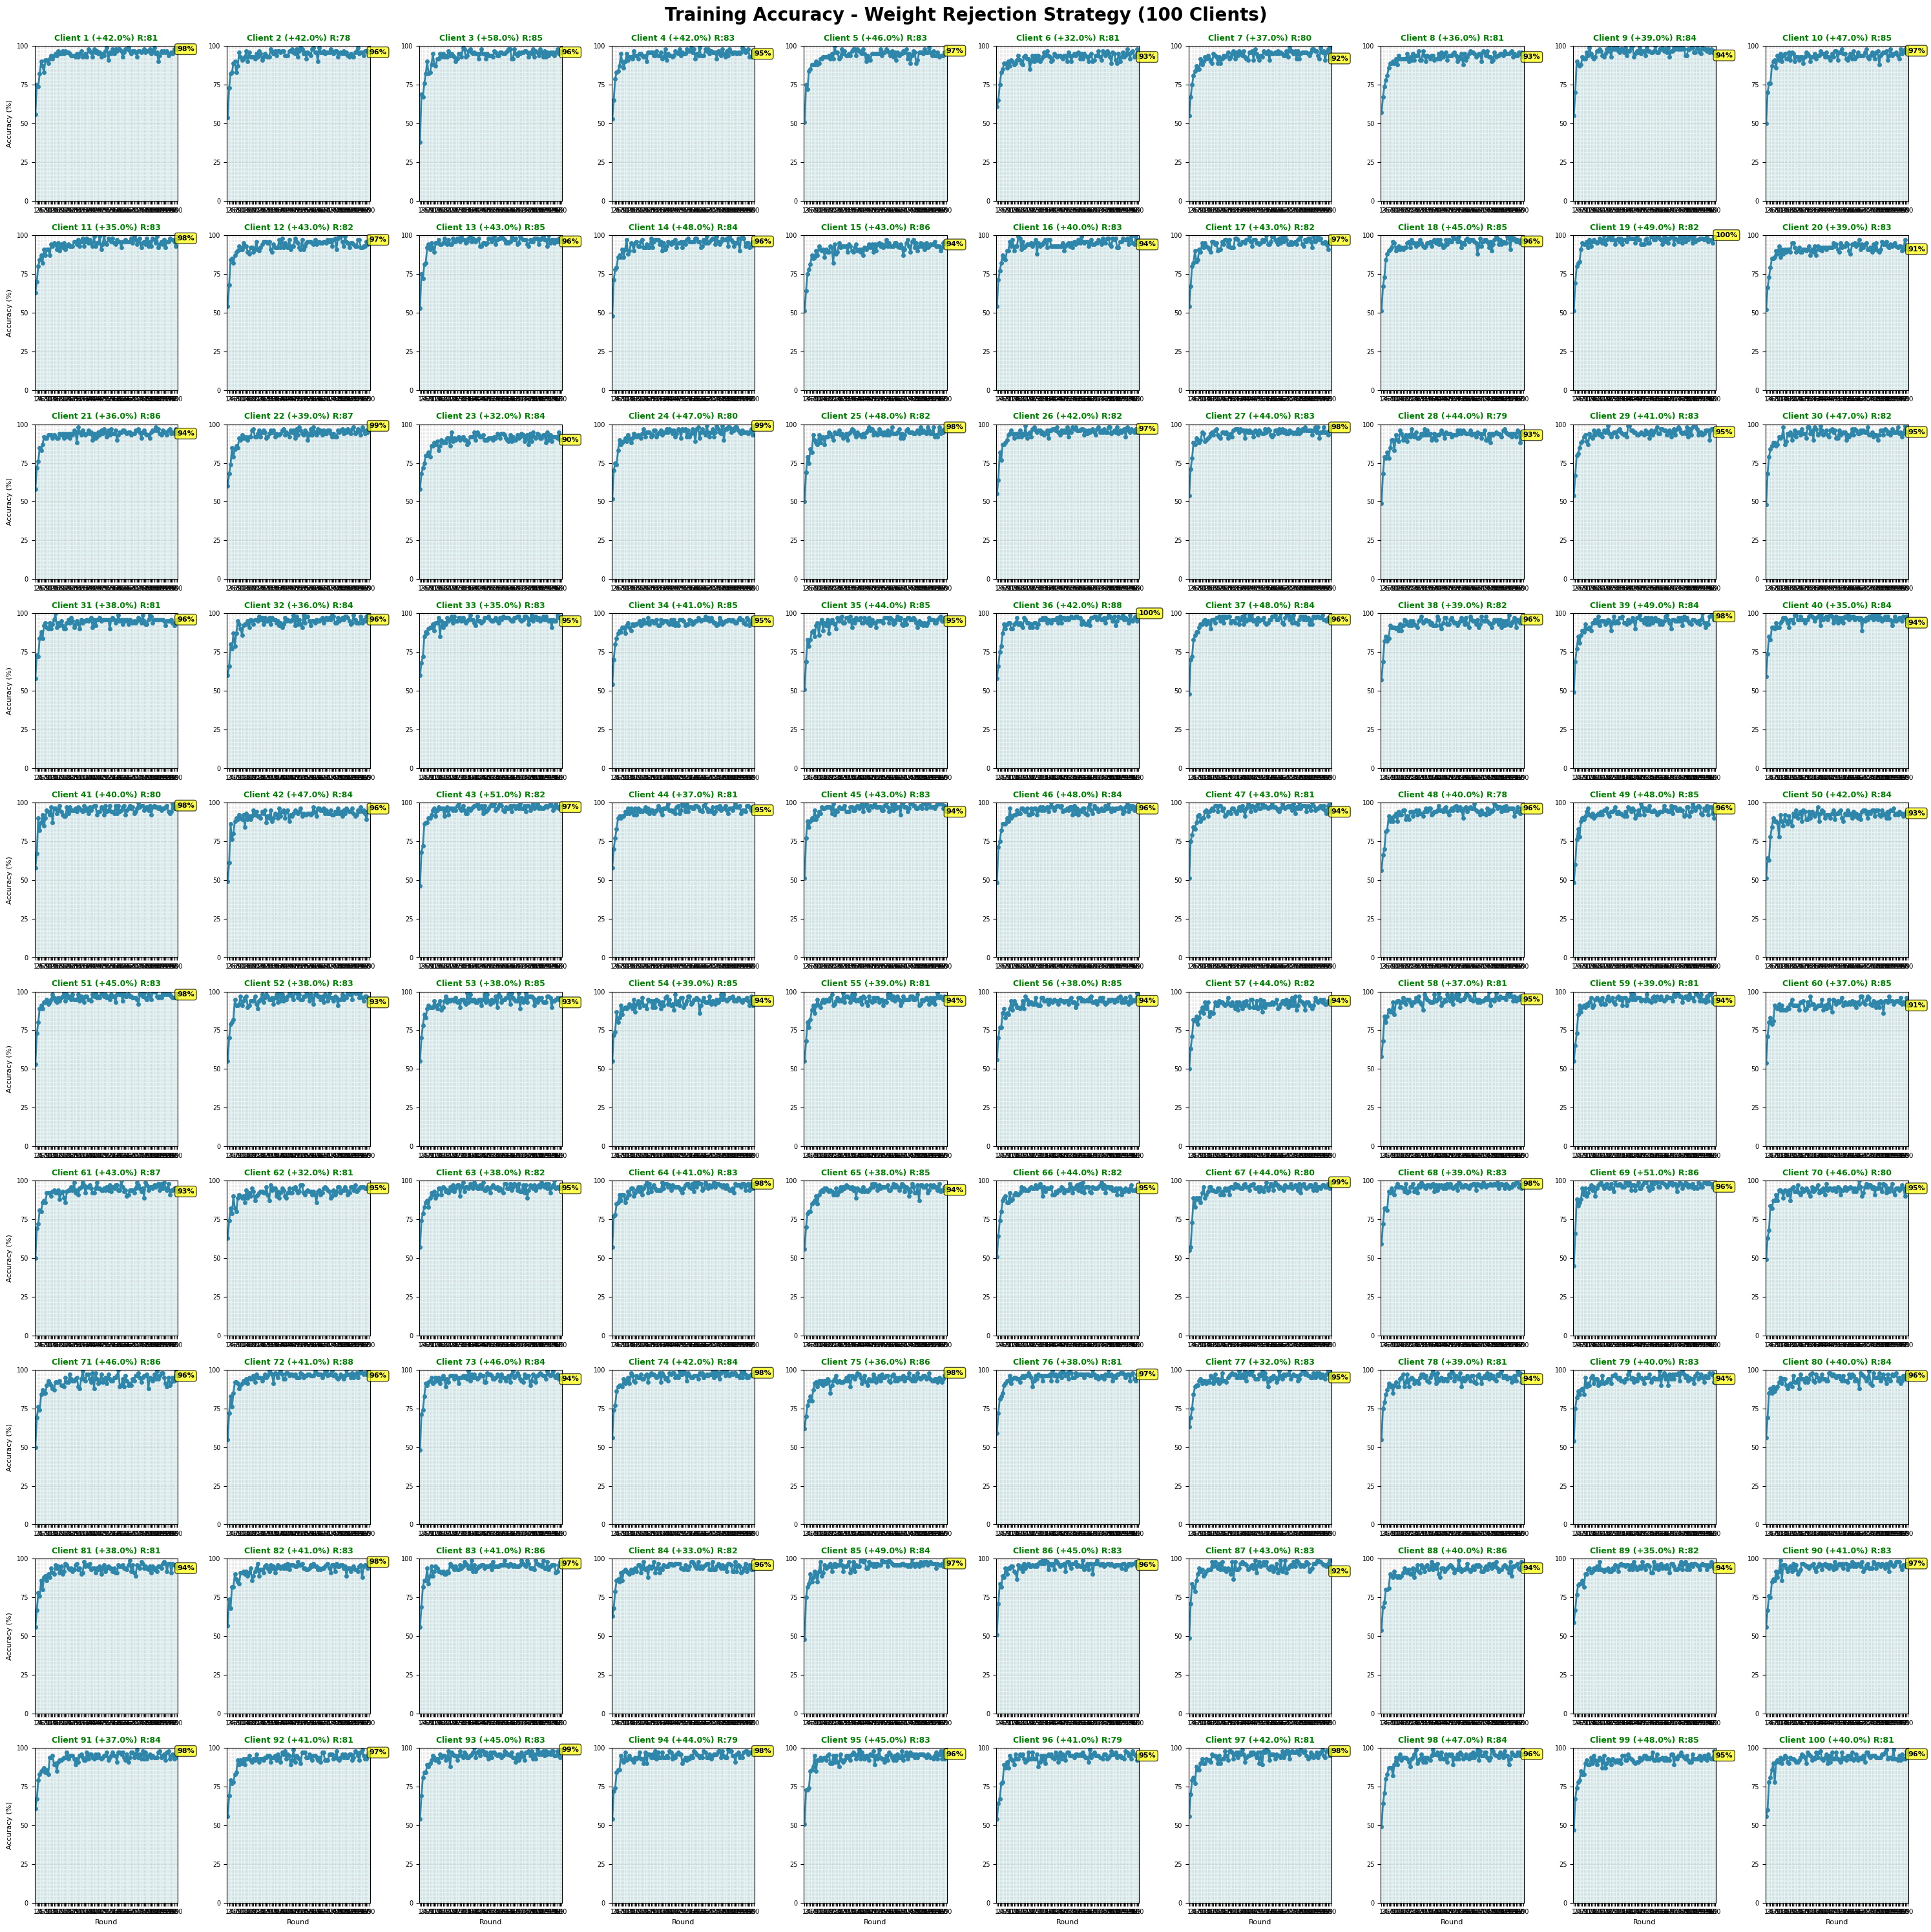

In [20]:
# Plot 1: Individual Training Accuracy for Each Client
print("Creating training accuracy plot for 100 clients...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Training Accuracy - Weight Rejection Strategy (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    train_accs = [acc * 100 for acc in client_train_acc_history[client_id]]
    final_acc = train_accs[-1]
    improvement = final_acc - train_accs[0]
    rejections = sum(client_rejections[client_id])
    
    ax.plot(rounds, train_accs, marker='o', linewidth=2, markersize=4, color='#2E86AB')
    ax.fill_between(rounds, train_accs, alpha=0.3, color='#A8DADC')
    
    ax.set_title(f'Client {client_id+1} ({improvement:+.1f}%) R:{rejections}', 
                fontsize=9, fontweight='bold', color='green')
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=8, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks(rounds)
    ax.set_xticklabels(rounds, fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
train_plot_path = os.path.join(RESULTS_DIR, 'training_accuracy_rejection.png')
plt.savefig(train_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {train_plot_path}")
plt.show()

Creating test accuracy plot for 100 clients...
✓ Saved: results_deviation_avg_median\test_accuracy_rejection.png


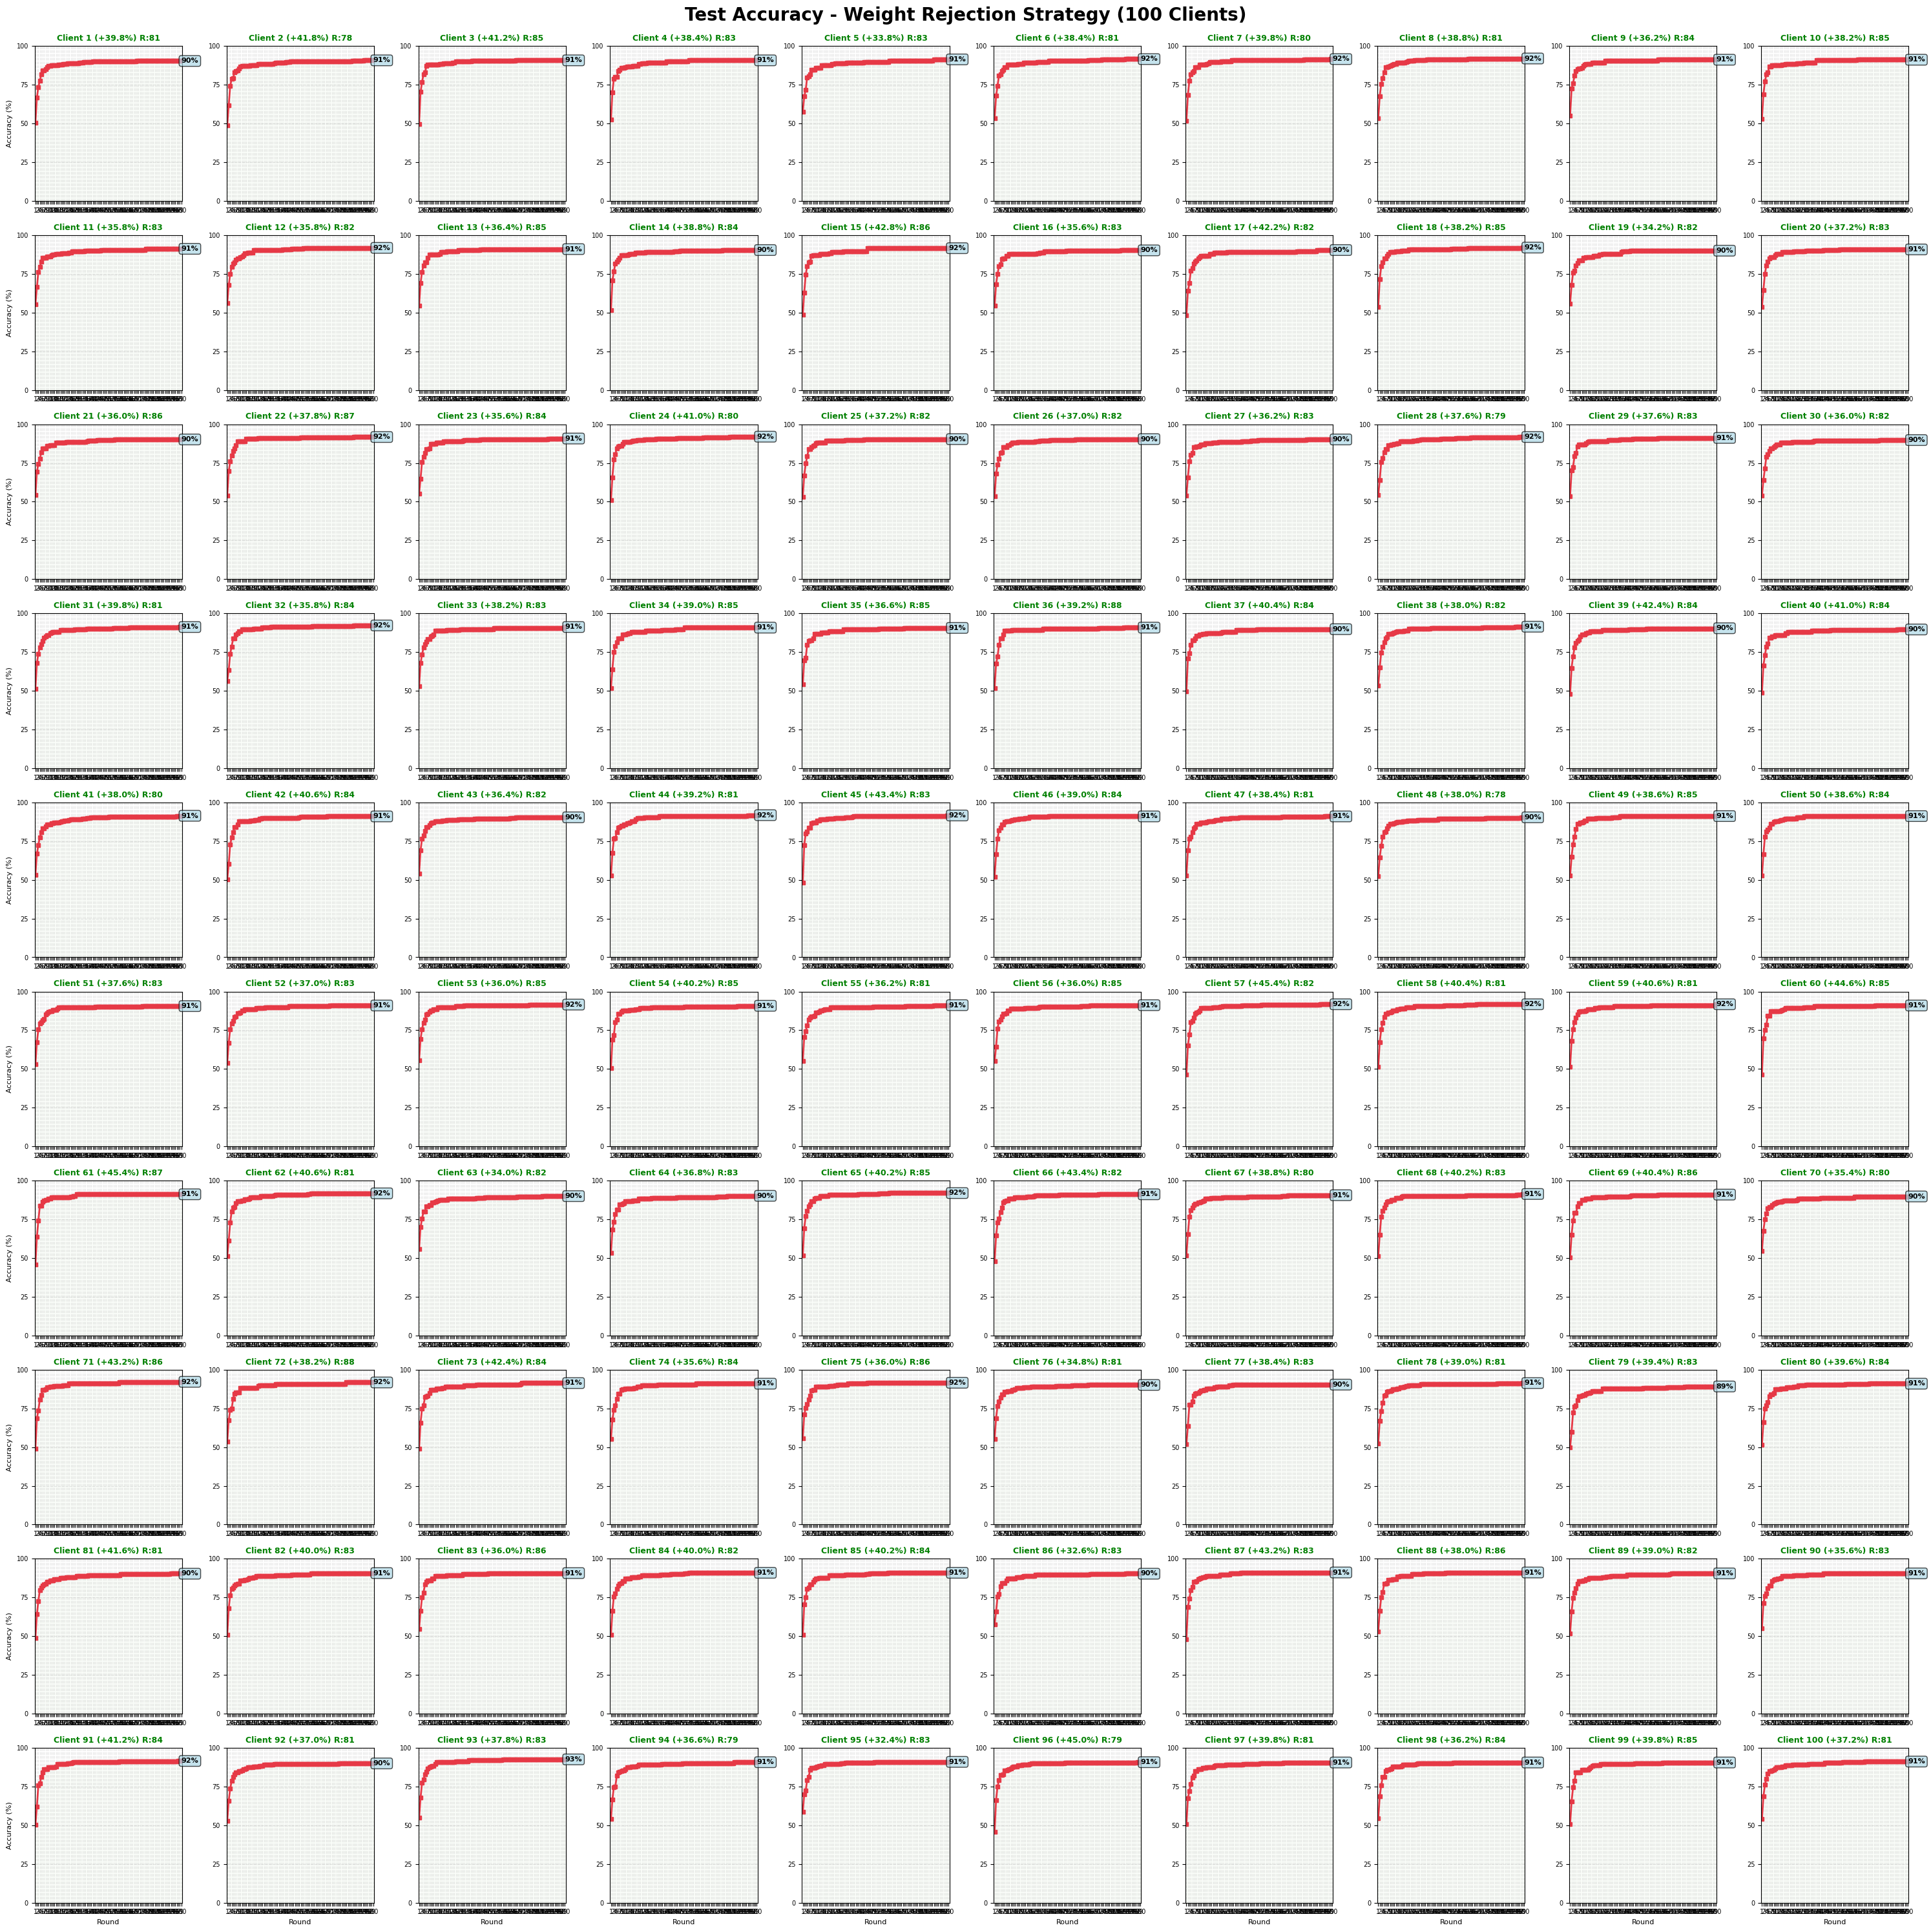

In [21]:
# Plot 2: Individual Test Accuracy for Each Client
print("Creating test accuracy plot for 100 clients...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Test Accuracy - Weight Rejection Strategy (100 Clients)', fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    test_accs = [acc * 100 for acc in client_test_acc_history[client_id]]
    final_acc = test_accs[-1]
    improvement = final_acc - test_accs[0]
    rejections = sum(client_rejections[client_id])
    
    ax.plot(rounds, test_accs, marker='s', linewidth=2, markersize=4, color='#E63946')
    ax.fill_between(rounds, test_accs, alpha=0.3, color='#F1FAEE')
    
    ax.set_title(f'Client {client_id+1} ({improvement:+.1f}%) R:{rejections}', 
                fontsize=9, fontweight='bold', color='green')
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=8, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks(rounds)
    ax.set_xticklabels(rounds, fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
test_plot_path = os.path.join(RESULTS_DIR, 'test_accuracy_rejection.png')
plt.savefig(test_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {test_plot_path}")
plt.show()

Creating rejection heatmap...
✓ Saved: results_deviation_avg_median\rejection_heatmap.png


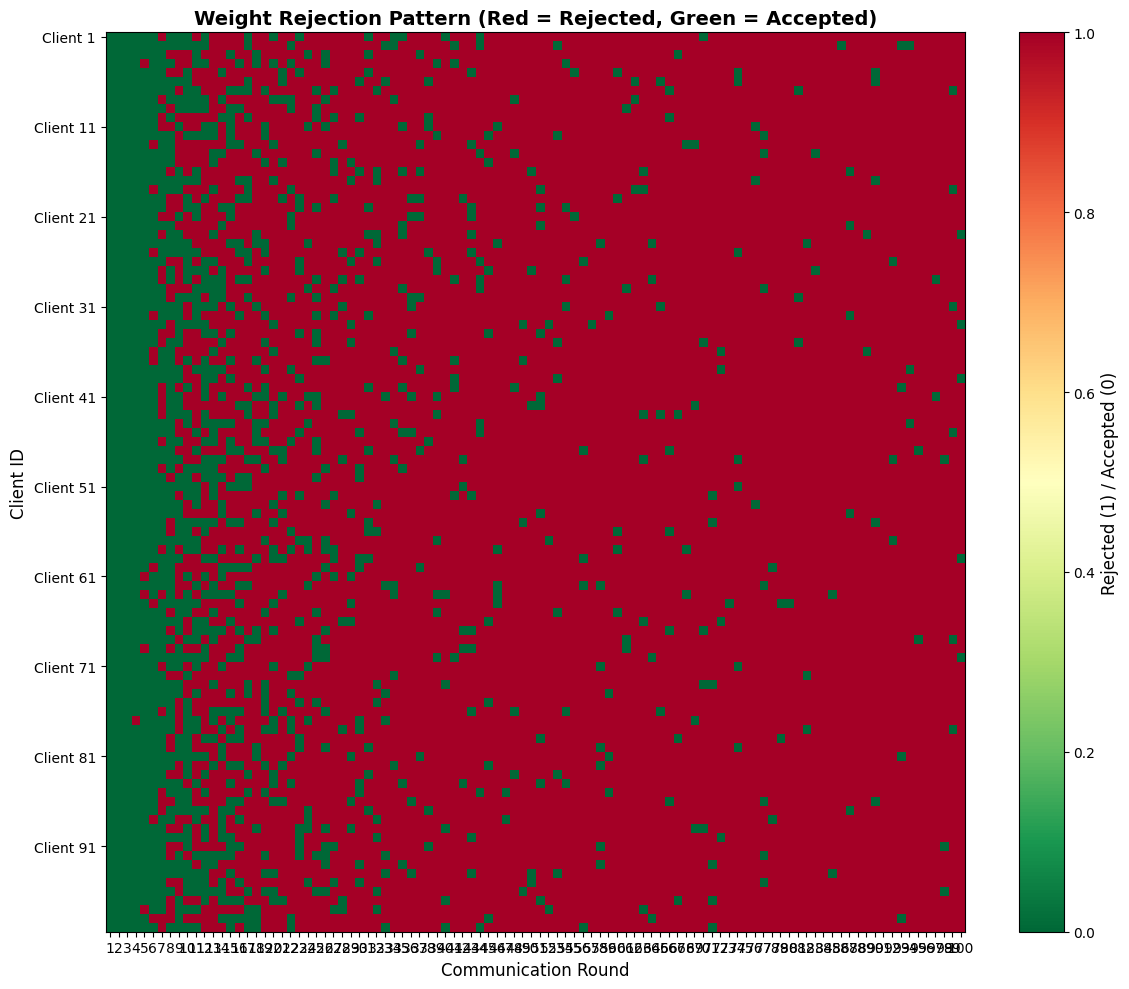

In [22]:
# Plot 3: Rejection Heatmap
print("Creating rejection heatmap...")

fig, ax = plt.subplots(figsize=(12, 10))

# Create rejection matrix (clients x rounds)
rejection_matrix = np.zeros((NUM_CLIENTS, NUM_ROUNDS))
for client_id in range(NUM_CLIENTS):
    for round_num in range(NUM_ROUNDS):
        rejection_matrix[client_id, round_num] = client_rejections[client_id][round_num]

im = ax.imshow(rejection_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rejected (1) / Accepted (0)', fontsize=12)

ax.set_title('Weight Rejection Pattern (Red = Rejected, Green = Accepted)', fontsize=14, fontweight='bold')
ax.set_xlabel('Communication Round', fontsize=12)
ax.set_ylabel('Client ID', fontsize=12)
ax.set_xticks(range(NUM_ROUNDS))
ax.set_xticklabels(range(1, NUM_ROUNDS + 1))
ax.set_yticks(range(0, NUM_CLIENTS, 10))
ax.set_yticklabels([f'Client {i+1}' for i in range(0, NUM_CLIENTS, 10)])

plt.tight_layout()
rejection_plot_path = os.path.join(RESULTS_DIR, 'rejection_heatmap.png')
plt.savefig(rejection_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {rejection_plot_path}")
plt.show()

Creating per-round rejection analysis...
✓ Saved: results_deviation_avg_median\rejection_analysis.png


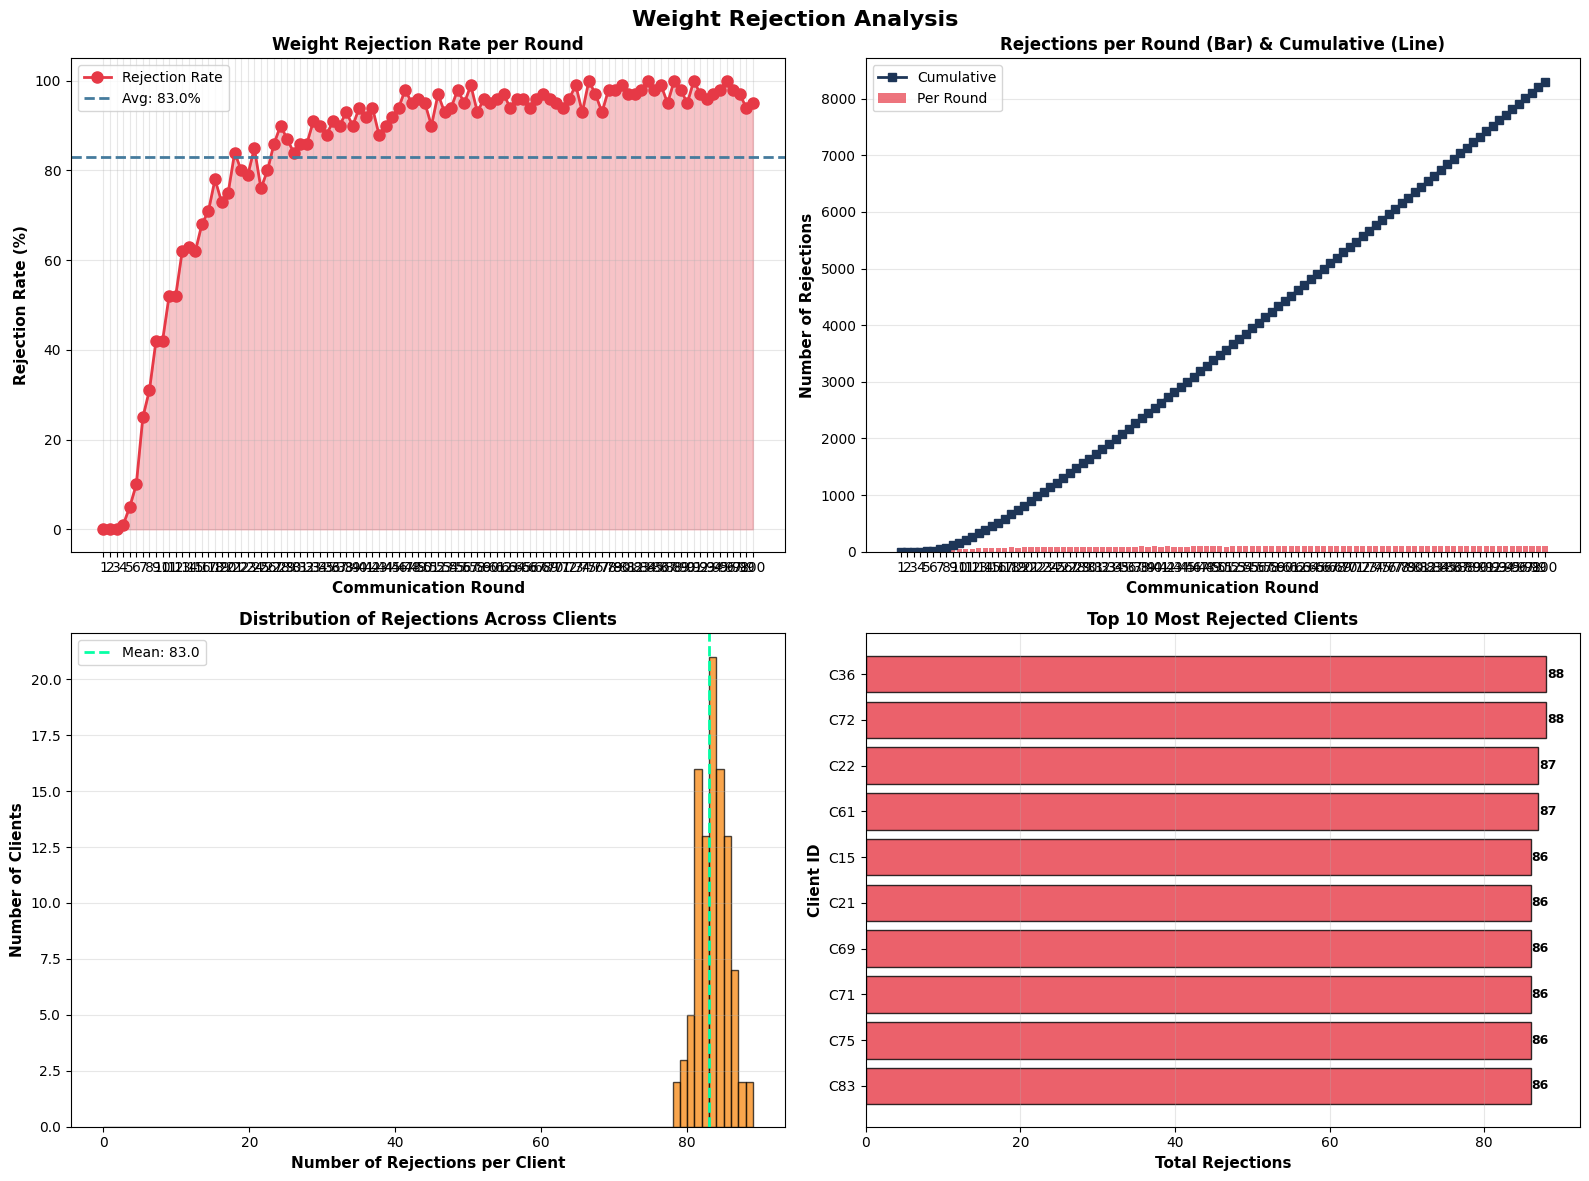


DETAILED REJECTION STATISTICS
Total possible updates: 10000
Total rejections: 8299
Overall rejection rate: 82.99%

Per-Round Statistics:
  Min rejections in a round: 0
  Max rejections in a round: 100
  Avg rejections per round: 82.99

Per-Client Statistics:
  Min rejections for a client: 78
  Max rejections for a client: 88
  Avg rejections per client: 82.99
  Std dev: 2.08


In [23]:
# Plot 4: Per-Round Rejection Analysis
print("Creating per-round rejection analysis...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Weight Rejection Analysis', fontsize=16, fontweight='bold')

# 4.1: Rejection Rate per Round
ax1 = axes[0, 0]
rounds = range(1, NUM_ROUNDS + 1)
rejections_per_round = []
acceptance_per_round = []

for round_num in range(NUM_ROUNDS):
    round_rejections = sum(client_rejections[client_id][round_num] for client_id in range(NUM_CLIENTS))
    rejections_per_round.append(round_rejections)
    acceptance_per_round.append(NUM_CLIENTS - round_rejections)

rejection_rates = [(r / NUM_CLIENTS) * 100 for r in rejections_per_round]

ax1.plot(rounds, rejection_rates, marker='o', linewidth=2, markersize=8, color='#E63946', label='Rejection Rate')
ax1.fill_between(rounds, rejection_rates, alpha=0.3, color='#E63946')
ax1.axhline(y=np.mean(rejection_rates), color='#457B9D', linestyle='--', linewidth=2, label=f'Avg: {np.mean(rejection_rates):.1f}%')
ax1.set_xlabel('Communication Round', fontsize=11, fontweight='bold')
ax1.set_ylabel('Rejection Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Weight Rejection Rate per Round', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xticks(rounds)

# 4.2: Cumulative Rejections per Round
ax2 = axes[0, 1]
cumulative_rejections = np.cumsum(rejections_per_round)
ax2.bar(rounds, rejections_per_round, color='#E63946', alpha=0.7, label='Per Round')
ax2.plot(rounds, cumulative_rejections, marker='s', linewidth=2, markersize=6, color='#1D3557', label='Cumulative')
ax2.set_xlabel('Communication Round', fontsize=11, fontweight='bold')
ax2.set_ylabel('Number of Rejections', fontsize=11, fontweight='bold')
ax2.set_title('Rejections per Round (Bar) & Cumulative (Line)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=10)
ax2.set_xticks(rounds)

# 4.3: Client Rejection Distribution
ax3 = axes[1, 0]
client_rejection_counts = [sum(client_rejections[client_id]) for client_id in range(NUM_CLIENTS)]
bins = range(0, max(client_rejection_counts) + 2)
ax3.hist(client_rejection_counts, bins=bins, color='#F77F00', alpha=0.7, edgecolor='black')
ax3.axvline(x=np.mean(client_rejection_counts), color='#06FFA5', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(client_rejection_counts):.1f}')
ax3.set_xlabel('Number of Rejections per Client', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Clients', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Rejections Across Clients', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(fontsize=10)

# 4.4: Top 10 Most Rejected Clients
ax4 = axes[1, 1]
client_ids_sorted = sorted(range(NUM_CLIENTS), key=lambda x: client_rejection_counts[x], reverse=True)
top_10_clients = client_ids_sorted[:10]
top_10_rejections = [client_rejection_counts[c] for c in top_10_clients]
client_labels = [f'C{c+1}' for c in top_10_clients]

bars = ax4.barh(client_labels, top_10_rejections, color='#E63946', alpha=0.8, edgecolor='black')
for i, (bar, count) in enumerate(zip(bars, top_10_rejections)):
    ax4.text(count + 0.1, i, f'{count}', va='center', fontweight='bold', fontsize=9)

ax4.set_xlabel('Total Rejections', fontsize=11, fontweight='bold')
ax4.set_ylabel('Client ID', fontsize=11, fontweight='bold')
ax4.set_title('Top 10 Most Rejected Clients', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

plt.tight_layout()
rejection_analysis_path = os.path.join(RESULTS_DIR, 'rejection_analysis.png')
plt.savefig(rejection_analysis_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {rejection_analysis_path}")
plt.show()

# Print rejection statistics
print("\n" + "=" * 60)
print("DETAILED REJECTION STATISTICS")
print("=" * 60)
print(f"Total possible updates: {NUM_CLIENTS * NUM_ROUNDS}")
print(f"Total rejections: {sum(client_rejection_counts)}")
print(f"Overall rejection rate: {(sum(client_rejection_counts) / (NUM_CLIENTS * NUM_ROUNDS)) * 100:.2f}%")
print(f"\nPer-Round Statistics:")
print(f"  Min rejections in a round: {min(rejections_per_round)}")
print(f"  Max rejections in a round: {max(rejections_per_round)}")
print(f"  Avg rejections per round: {np.mean(rejections_per_round):.2f}")
print(f"\nPer-Client Statistics:")
print(f"  Min rejections for a client: {min(client_rejection_counts)}")
print(f"  Max rejections for a client: {max(client_rejection_counts)}")
print(f"  Avg rejections per client: {np.mean(client_rejection_counts):.2f}")
print(f"  Std dev: {np.std(client_rejection_counts):.2f}")
print("=" * 60)

Creating deviation vs round plot...
✓ Saved: results_deviation_avg_median\deviation_aggregation_decision.png


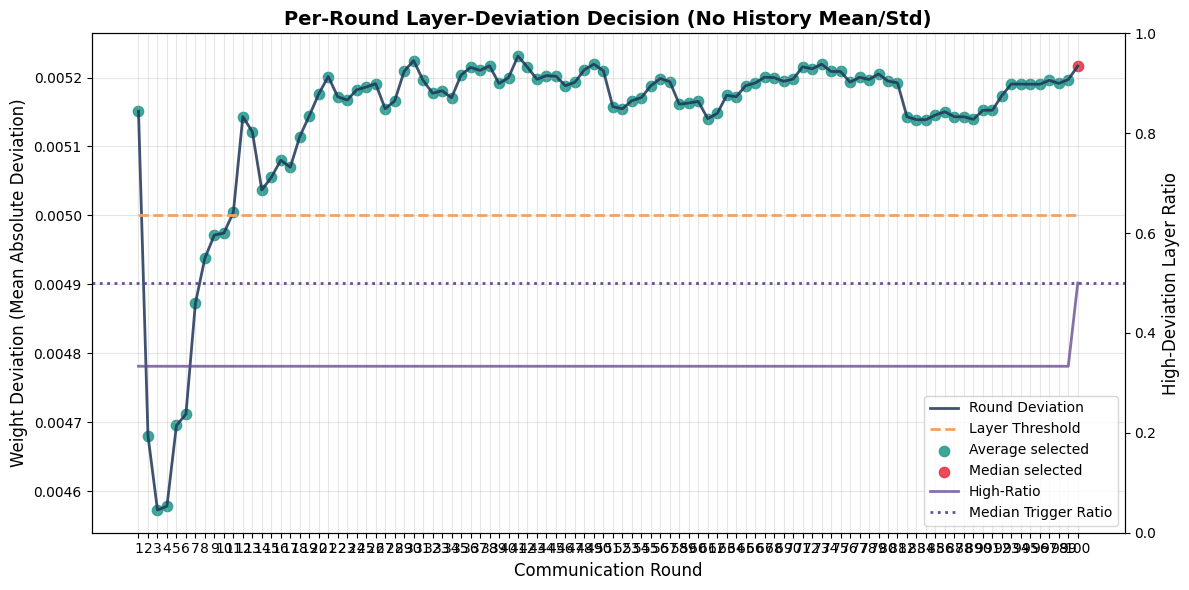

In [24]:
# Plot 5: Round-wise Weight Deviation with Aggregation Decision
print("Creating deviation vs round plot...")

rounds = np.arange(1, NUM_ROUNDS + 1)
deviations = np.array(round_deviation_history)
thresholds = np.array(round_threshold_history)
high_ratios = np.array(round_high_ratio_history)

avg_round_idx = [i + 1 for i, m in enumerate(round_aggregation_method) if m == 'average']
avg_round_dev = [round_deviation_history[i] for i, m in enumerate(round_aggregation_method) if m == 'average']
median_round_idx = [i + 1 for i, m in enumerate(round_aggregation_method) if m == 'median']
median_round_dev = [round_deviation_history[i] for i, m in enumerate(round_aggregation_method) if m == 'median']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(rounds, deviations, color='#1D3557', linewidth=2, alpha=0.85, label='Round Deviation')
ax1.plot(rounds, thresholds, color='#F4A261', linestyle='--', linewidth=2, label='Layer Threshold')
ax1.scatter(avg_round_idx, avg_round_dev, color='#2A9D8F', s=55, alpha=0.9, label='Average selected')
ax1.scatter(median_round_idx, median_round_dev, color='#E63946', s=55, alpha=0.9, label='Median selected')
ax1.set_xlabel('Communication Round', fontsize=12)
ax1.set_ylabel('Weight Deviation (Mean Absolute Deviation)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(rounds)

ax2 = ax1.twinx()
ax2.plot(rounds, high_ratios, color='#6A4C93', linewidth=2, alpha=0.8, label='High-Ratio')
ax2.axhline(y=MEDIAN_TRIGGER_RATIO, color='#6A4C93', linestyle=':', linewidth=2, label='Median Trigger Ratio')
ax2.set_ylabel('High-Deviation Layer Ratio', fontsize=12)
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='best')

plt.title('Per-Round Layer-Deviation Decision (No History Mean/Std)', fontsize=14, fontweight='bold')
deviation_plot_path = os.path.join(RESULTS_DIR, 'deviation_aggregation_decision.png')
plt.tight_layout()
plt.savefig(deviation_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {deviation_plot_path}")
plt.show()

## Save Model and Results

In [25]:
# Save the final global model
model_save_path = os.path.join(RESULTS_DIR, 'federated_model_deviation_avg_median.h5')
global_model.save(model_save_path)
print(f"✓ Model saved: {model_save_path}")

# Save accuracy history and rejection data
history_save_path = os.path.join(RESULTS_DIR, 'accuracy_deviation_avg_median_history.npz')
np.savez(history_save_path, 
         train_acc=np.array(client_train_acc_history),
         test_acc=np.array(client_test_acc_history),
         rejections=np.array(client_rejections),
         round_deviation=np.array(round_deviation_history),
         round_threshold=np.array(round_threshold_history),
         round_high_ratio=np.array(round_high_ratio_history),
         aggregation_method=np.array(round_aggregation_method))
print(f"✓ Accuracy, rejection, and aggregation history saved: {history_save_path}")

✓ Model saved: results_deviation_avg_median\federated_model_deviation_avg_median.h5
✓ Accuracy, rejection, and aggregation history saved: results_deviation_avg_median\accuracy_deviation_avg_median_history.npz


In [26]:
# Save round-wise deviation and aggregation decisions as CSV
decision_csv_path = os.path.join(RESULTS_DIR, 'round_deviation_aggregation.csv')
decision_df = pd.DataFrame({
    'round': np.arange(1, NUM_ROUNDS + 1),
    'deviation': np.array(round_deviation_history, dtype=float),
    'threshold': np.array(round_threshold_history, dtype=float),
    'high_ratio': np.array(round_high_ratio_history, dtype=float),
    'aggregation_method': np.array(round_aggregation_method)
})
decision_df.to_csv(decision_csv_path, index=False)

# Save the round-wise weight-table summary as CSV
weight_table_csv_path = os.path.join(RESULTS_DIR, 'round_weight_table_summary.csv')
pd.DataFrame(round_weight_table_summary).to_csv(weight_table_csv_path, index=False)

print(f"✓ Deviation aggregation CSV saved: {decision_csv_path}")
print(f"✓ Weight-table summary CSV saved: {weight_table_csv_path}")

✓ Deviation aggregation CSV saved: results_deviation_avg_median\round_deviation_aggregation.csv
✓ Weight-table summary CSV saved: results_deviation_avg_median\round_weight_table_summary.csv


## Summary

In [27]:
# Final comprehensive summary
print("\n" + "=" * 60)
print("FEDERATED LEARNING WITH WEIGHT REJECTION + ADAPTIVE AGGREGATION - SUMMARY")
print("=" * 60)
print(f"Algorithm: Per-round Layer-Deviation Adaptive (FedAvg/FedMedian) with Per-Client Weight Rejection")
print(f"Strategy: Keep previous weights if test accuracy doesn't improve")
print(f"Round Aggregation Rule: use current round only (no previous deviation mean/std)")
print(f"Decision Rule: if fraction(layer_mad > {LAYER_DEVIATION_THRESHOLD}) >= {MEDIAN_TRIGGER_RATIO:.2f} -> Median else Average")
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Samples per Client: 100 (balanced)")
print(f"Test Samples: 500 (common)")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"\nFinal Results:")
print(f"  Average Training Accuracy: {avg_final_train:.2f}%")
print(f"  Average Test Accuracy: {avg_final_test:.2f}%")
print(f"  Training Acc Std Dev: {np.std(final_train_accs):.2f}%")
print(f"  Test Acc Std Dev: {np.std(final_test_accs):.2f}%")
print(f"\nRejection Statistics:")
print(f"  Total Weight Updates: {NUM_CLIENTS * NUM_ROUNDS}")
print(f"  Accepted: {NUM_CLIENTS * NUM_ROUNDS - total_rejections}")
print(f"  Rejected: {total_rejections} ({total_rejections / (NUM_CLIENTS * NUM_ROUNDS) * 100:.2f}%)")
print(f"  Avg Rejections per Client: {avg_rejections:.2f}/{NUM_ROUNDS} rounds")
print(f"\nAdaptive Aggregation:")
print(f"  Average rounds: {num_avg_rounds}")
print(f"  Median rounds: {num_median_rounds}")
print(f"  Mean round deviation: {mean_round_deviation:.6f}")
print(f"  Max round deviation: {max_round_deviation:.6f}")
print(f"  Layer threshold used: {mean_threshold:.6f}")
print(f"  Mean high-ratio: {mean_high_ratio:.2f}")
print(f"\nSaved Files:")
print(f"  - Model: {model_save_path}")
print(f"  - History: {history_save_path}")
print(f"  - Training plot: {train_plot_path}")
print(f"  - Test plot: {test_plot_path}")
print(f"  - Rejection heatmap: {rejection_plot_path}")
print(f"  - Rejection analysis: {rejection_analysis_path}")
print(f"  - Deviation plot: {deviation_plot_path}")
print(f"  - Decision CSV: {decision_csv_path}")
print(f"  - Weight-table CSV: {weight_table_csv_path}")
print("=" * 60)


FEDERATED LEARNING WITH WEIGHT REJECTION + ADAPTIVE AGGREGATION - SUMMARY
Algorithm: Per-round Layer-Deviation Adaptive (FedAvg/FedMedian) with Per-Client Weight Rejection
Strategy: Keep previous weights if test accuracy doesn't improve
Round Aggregation Rule: use current round only (no previous deviation mean/std)
Decision Rule: if fraction(layer_mad > 0.005) >= 0.50 -> Median else Average
Number of Clients: 100
Samples per Client: 100 (balanced)
Test Samples: 500 (common)
Communication Rounds: 100
Local Epochs per Round: 10

Final Results:
  Average Training Accuracy: 95.63%
  Average Test Accuracy: 90.99%
  Training Acc Std Dev: 1.99%
  Test Acc Std Dev: 0.64%

Rejection Statistics:
  Total Weight Updates: 10000
  Accepted: 1701
  Rejected: 8299 (82.99%)
  Avg Rejections per Client: 82.99/100 rounds

Adaptive Aggregation:
  Average rounds: 99
  Median rounds: 1
  Mean round deviation: 0.005139
  Max round deviation: 0.005231
  Layer threshold used: 0.005000
  Mean high-ratio: 0.34
